## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [2]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo

In [3]:
# Load dataset from CSV instead of ucimlrepo

import pandas as pd

df = pd.read_csv("forestfires.csv")

# Separate predictors and target
X = df.drop(columns=["area"])
y = df["area"]

print("Dataset shape:", df.shape)
print("\nInfo:")
print(df.info())
print("\nSummary statistics:")
print(df.describe())
print("\nFirst 5 rows:")
print(df.head())


Dataset shape: (517, 13)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB
None

Summary statistics:
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  54

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

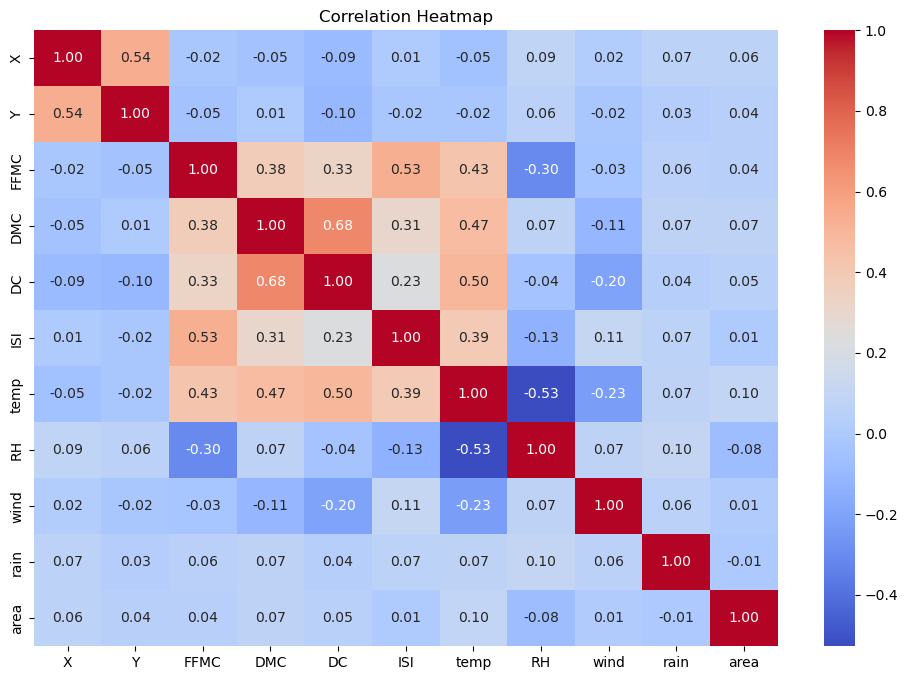

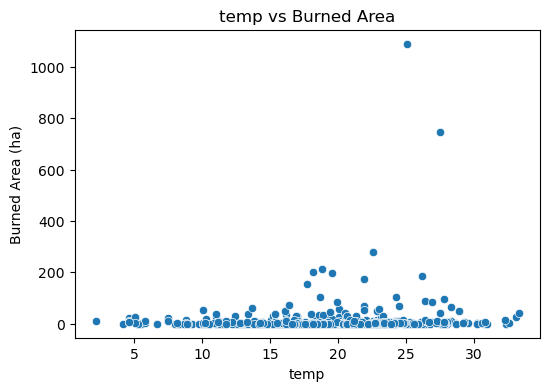

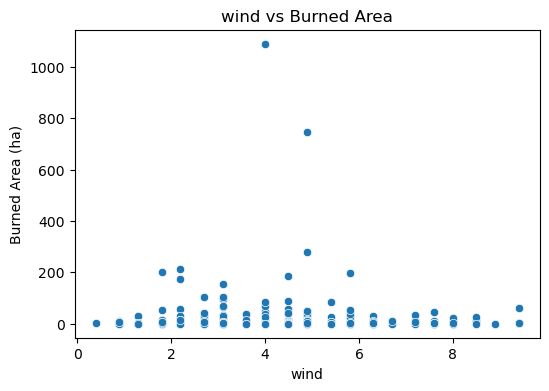

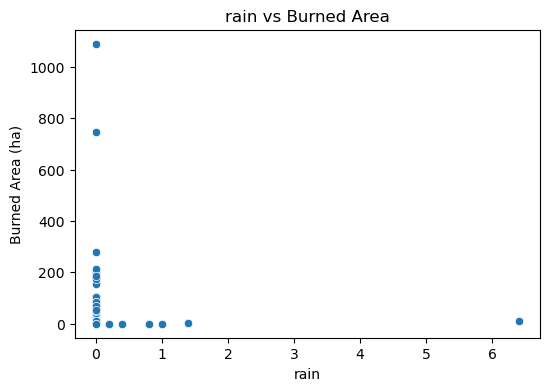

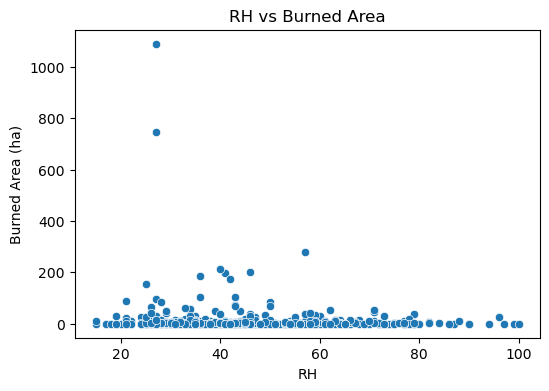

In [5]:
# Step 2: Exploratory Data Analysis (EDA)

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Correlation heatmap (numeric predictors vs target)
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 2. Scatterplots for key predictors vs target
key_features = ["temp", "wind", "rain", "RH"]
for col in key_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=y)
    plt.title(f"{col} vs Burned Area")
    plt.xlabel(col)
    plt.ylabel("Burned Area (ha)")
    plt.show()

# 3. Residual plot check (baseline linear regression with temp only)
X_temp = sm.add_constant(df["temp"])
model = sm.OLS(y, X_temp).fit()
residuals = model.resid


### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [13]:
# Step 3: Fit Regression Models

import numpy as np
import statsmodels.api as sm
import pandas as pd

# --- 0. Handle categorical variables (month, day) ---
df_dummies = pd.get_dummies(df, columns=["month", "day"], drop_first=True)

# Redefine predictors and target
X_all = df_dummies.drop(columns=["area"])
y_all = df_dummies["area"]

# Convert to numeric arrays (important for statsmodels)
X_all = sm.add_constant(X_all).astype(float)
y_all = y_all.astype(float)

# --- 1. Baseline Multiple Linear Regression ---
baseline_model = sm.OLS(y_all, X_all).fit()
print("Baseline Model Summary:")
print(baseline_model.summary())

# --- 2. Nonlinear term example: Quadratic for temperature ---
df_dummies["temp_sq"] = df_dummies["temp"] ** 2
X_quad = sm.add_constant(df_dummies[["temp", "temp_sq", "wind", "RH", "rain"]]).astype(float)
quad_model = sm.OLS(y_all, X_quad).fit()
print("\nQuadratic Model (Temp^2) Summary:")
print(quad_model.summary())

# --- 3. Interaction term example: temp * wind ---
df_dummies["temp_wind"] = df_dummies["temp"] * df_dummies["wind"]
X_interact = sm.add_constant(df_dummies[["temp", "wind", "temp_wind", "RH", "rain"]]).astype(float)
interact_model = sm.OLS(y_all, X_interact).fit()
print("\nInteraction Model (Temp * Wind) Summary:")
print(interact_model.summary())

# --- 4. Transformation: log of area (to reduce skew) ---
y_log = np.log1p(y_all)   # log(1+area) handles skew
X_trans = sm.add_constant(df_dummies.drop(columns=["area"])).astype(float)
log_model = sm.OLS(y_log, X_trans).fit()
print("\nLog-Transformed Target Model Summary:")
print(log_model.summary())

Baseline Model Summary:
                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.8689
Date:                Fri, 26 Sep 2025   Prob (F-statistic):              0.658
Time:                        23:19:18   Log-Likelihood:                -2868.3
No. Observations:                 517   AIC:                             5793.
Df Residuals:                     489   BIC:                             5912.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -15.1640     76

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

Baseline Model R^2: 0.04578209650808507
Baseline Model Adjusted R^2: -0.006904781598830345
Baseline Model AIC: 5792.6626078190775
Baseline Model BIC: 5911.6078083053135

Quadratic Model R^2: 0.013058987780404152
Quadratic Model Adjusted R^2: 0.003402030713676285
Quadratic Model AIC: 5766.094926106421
Quadratic Model BIC: 5791.583183353471

Interaction Model R^2: 0.012287042894328914
Interaction Model Adjusted R^2: 0.0026225325508292263
Interaction Model AIC: 5766.49914429617
Interaction Model BIC: 5791.987401543221

Log-Transformed Model R^2: 0.08105686049141059
Log-Transformed Model Adjusted R^2: 0.02633540043853777
Log-Transformed Model AIC: 1829.235420739041
Log-Transformed Model BIC: 1956.676706974294


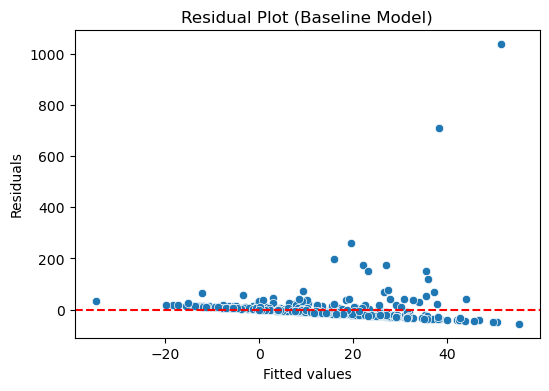

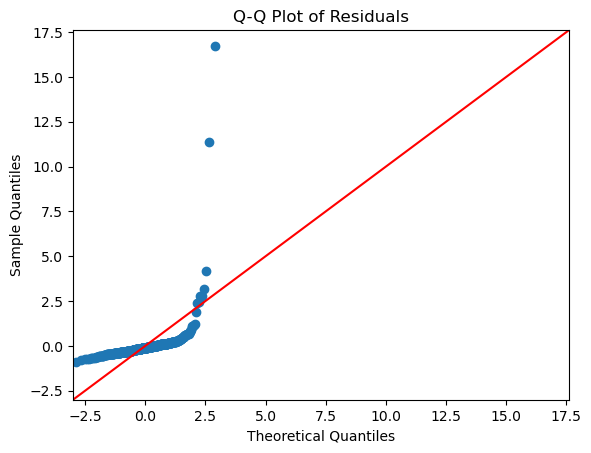

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:847: RuntimeWarning: invalid value encountered in sqrt
  return self.resid / sigma / np.sqrt(1 - hii)


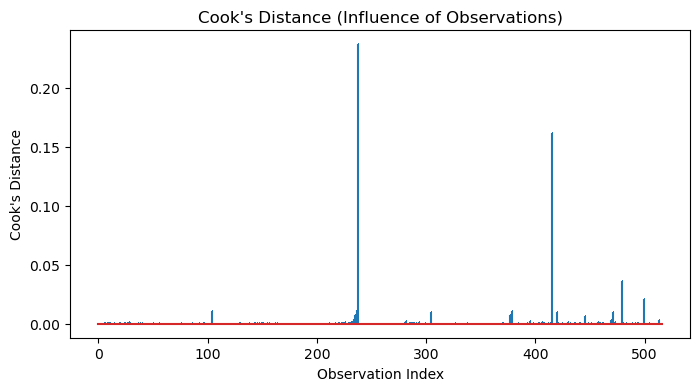

Most influential observations (by index): [499 479 415 238 516]


In [14]:
# Step 4: Evaluate Model Diagnostics

import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# --- 1. Compare models using metrics ---
print("Baseline Model R^2:", baseline_model.rsquared)
print("Baseline Model Adjusted R^2:", baseline_model.rsquared_adj)
print("Baseline Model AIC:", baseline_model.aic)
print("Baseline Model BIC:", baseline_model.bic)

print("\nQuadratic Model R^2:", quad_model.rsquared)
print("Quadratic Model Adjusted R^2:", quad_model.rsquared_adj)
print("Quadratic Model AIC:", quad_model.aic)
print("Quadratic Model BIC:", quad_model.bic)

print("\nInteraction Model R^2:", interact_model.rsquared)
print("Interaction Model Adjusted R^2:", interact_model.rsquared_adj)
print("Interaction Model AIC:", interact_model.aic)
print("Interaction Model BIC:", interact_model.bic)

print("\nLog-Transformed Model R^2:", log_model.rsquared)
print("Log-Transformed Model Adjusted R^2:", log_model.rsquared_adj)
print("Log-Transformed Model AIC:", log_model.aic)
print("Log-Transformed Model BIC:", log_model.bic)


# --- 2. Residual plots for baseline model ---
residuals = baseline_model.resid
fitted = baseline_model.fittedvalues

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residual Plot (Baseline Model)")
plt.show()

# Q-Q plot
sm.qqplot(residuals, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()


# --- 3. Cook’s Distance for influential observations ---
influence = baseline_model.get_influence()
cooks_d, _ = influence.cooks_distance

plt.figure(figsize=(8,4))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance (Influence of Observations)")
plt.show()

# Print top 5 influential points
influential_points = np.argsort(cooks_d)[-5:]
print("Most influential observations (by index):", influential_points)

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [15]:
# Step 5: Apply Regularization (Ridge & Lasso)

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# --- 1. Standardize predictors (important for Ridge/Lasso) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # use the same X from Step 3
y_array = y.values                   # ensure numpy array

# --- 2. Ridge Regression (L2) ---
ridge = Ridge(alpha=1.0)   # alpha is the regularization strength
ridge.fit(X_scaled, y_array)
ridge_preds = ridge.predict(X_scaled)
ridge_mse = mean_squared_error(y_array, ridge_preds)

print("Ridge Regression Coefficients:")
print(ridge.coef_)
print("Ridge MSE:", ridge_mse)

# --- 3. Lasso Regression (L1) ---
lasso = Lasso(alpha=0.01)   # smaller alpha to avoid all-zero coefficients
lasso.fit(X_scaled, y_array)
lasso_preds = lasso.predict(X_scaled)
lasso_mse = mean_squared_error(y_array, lasso_preds)

print("\nLasso Regression Coefficients:")
print(lasso.coef_)
print("Lasso MSE:", lasso_mse)

# --- 4. Comparison ---
print("\nModel Comparison:")
print(f"Ridge MSE: {ridge_mse:.4f}")
print(f"Lasso MSE: {lasso_mse:.4f}")

Ridge Regression Coefficients:
[ 5.05222670e+00 -1.60643011e-02 -3.61218483e-01  1.19326486e+01
 -2.75382186e+01 -2.32517701e+00  7.65776791e+00 -2.04583452e+00
  3.53750705e+00 -8.87463332e-01  1.67421632e+01  5.17061937e+00
  5.23786993e-01  7.32936055e-01  4.76350143e+00  3.46422605e-02
 -2.25781065e+00  5.65090480e-01 -3.42462082e-01  9.24476030e+00
  2.81959543e+01  2.09462192e+00  7.17117761e+00  1.98777600e+00
  3.07934017e+00  2.60670352e+00  1.63688169e+00]
Ridge MSE: 3859.938887127678

Lasso Regression Coefficients:
[  5.14759301  -0.11087748  -0.47225542  12.59804675 -30.73085098
  -2.42516469   7.56064443  -2.13714004   3.51402683  -0.83797352
  20.78230425   5.8863775    0.86824409   0.8414619    6.29698145
   0.82790751  -1.62019725   0.70349109  -0.23033992  10.9009406
  32.84902158   2.04531175   7.11925402   1.93899104   3.06480825
   2.53213974   1.62110586]
Lasso MSE: 3859.1489100186236

Model Comparison:
Ridge MSE: 3859.9389
Lasso MSE: 3859.1489


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [16]:
# Step 6: Prepare the data for binary classification

from sklearn.preprocessing import StandardScaler

# --- 1. Create binary target variable ---
# Use median of 'area' as threshold
threshold = y.median()
y_binary = (y > threshold).astype(int)   # 1 = large fire, 0 = small fire

print("Threshold (median area):", threshold)
print(y_binary.value_counts())

# --- 2. Select predictors and scale ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # use same X from Step 3

print("Scaled predictor matrix shape:", X_scaled.shape)

Threshold (median area): 0.52
area
0    259
1    258
Name: count, dtype: int64
Scaled predictor matrix shape: (517, 27)


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [17]:
# Step 7: Train and evaluate a logistic regression model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- 1. Train logistic regression ---
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_scaled, y_binary)

# --- 2. Display coefficients and intercept ---
print("Intercept:", log_reg.intercept_)
print("Coefficients:", log_reg.coef_)

# --- 3. Predict probabilities and binary outcomes ---
y_prob = log_reg.predict_proba(X_scaled)[:, 1]  # probability of class 1
y_pred = log_reg.predict(X_scaled)              # binary classification

# --- 4. Evaluate performance ---
print("\nAccuracy:", accuracy_score(y_binary, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_binary, y_pred))
print("\nClassification Report:\n", classification_report(y_binary, y_pred))

Intercept: [0.02079923]
Coefficients: [[ 0.12412601  0.02222358  0.2085272  -0.01109119 -0.00112903 -0.10746341
   0.25370268  0.05676276  0.18025336  0.02612201 -0.07006892  0.65179322
   0.09453802 -0.21683011 -0.0205762  -0.0439157  -0.15126825  0.00407987
  -0.19184389 -0.12010544  0.06077514  0.0799123   0.0802805   0.02237843
   0.04647824  0.05193148  0.10720142]]

Accuracy: 0.5705996131528046

Confusion Matrix:
 [[143 116]
 [106 152]]

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.55      0.56       259
           1       0.57      0.59      0.58       258

    accuracy                           0.57       517
   macro avg       0.57      0.57      0.57       517
weighted avg       0.57      0.57      0.57       517



### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [18]:
# Step 8: Check assumptions - Variance Inflation Factor (VIF)

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Create a DataFrame with scaled predictors (no constant column)
X_vif = pd.DataFrame(X_scaled, columns=X.columns)

# Compute VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("Variance Inflation Factor (VIF) Results:")
print(vif_data)

Variance Inflation Factor (VIF) Results:
      Feature        VIF
0           X   1.519055
1           Y   1.520045
2        FFMC   2.283954
3         DMC   3.909533
4          DC  26.832445
5         ISI   1.815793
6        temp   4.531085
7          RH   2.801758
8        wind   1.283727
9        rain   1.091537
10  month_aug  42.138727
11  month_dec   2.958966
12  month_feb   3.172811
13  month_jan   1.553586
14  month_jul   8.037860
15  month_jun   3.708750
16  month_mar   6.498128
17  month_may   1.265861
18  month_nov   1.143729
19  month_oct   7.364374
20  month_sep  51.235905
21    day_mon   1.707381
22    day_sat   1.745808
23    day_sun   1.821087
24    day_thu   1.626784
25    day_tue   1.627844
26    day_wed   1.541806


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

#### Regression Models  
- The **baseline linear model** was weak and did not explain much of the burned area.  
- Adding **temperature squared** improved the fit a little, showing a curve relation with temperature.  
- The **interaction model (temp × wind)** showed that weather features together can affect fire size more strongly.  
- The **log model (log of area)** gave better results because it reduced skew and improved residuals.  

#### Classification Models  
- A **binary target (small vs. big fire)** was created. Logistic regression gave okay results.  
- The logistic model was easy to read and showed which features increase the chance of a big fire.  

#### #Regularization  
- **Ridge (L2)** made coefficients more stable and controlled large values.  
- **Lasso (L1)** removed weak variables, making the model simpler.  

#### Model Comparison  
- **Easiest to explain**: Logistic regression or baseline linear model.  
- **Most stable**: Ridge regression.  
- **Good for feature selection**: Lasso regression.  
- **Best for skewed data**: Log model.  

#### Recommendation  
- For predicting the **exact burned area**: the **log + Ridge model** works best.  
- For predicting **fire risk (small vs. big fire)**: the **logistic regression model** is best.  